In [29]:
import pandas as pd
import numpy as np
import os
from pathlib import Path

BASE_DIR = ROOT = Path.cwd().parent
PATH_DATA = os.path.join(BASE_DIR, 'data', 'processed', 'processed_jobs.csv')

df = pd.read_csv(PATH_DATA, parse_dates=['datetime'], index_col='datetime')


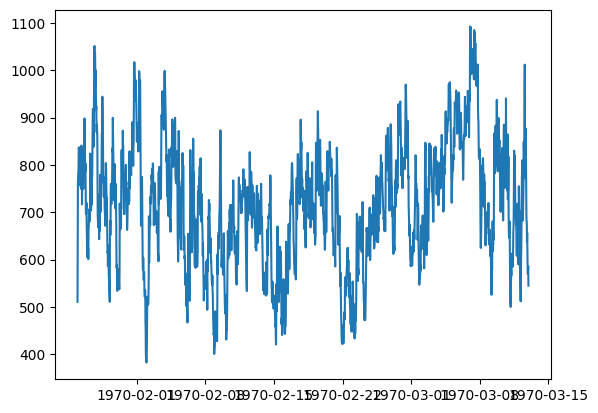

In [30]:
import matplotlib.pyplot as plt

plt.plot(df['util_mean'])


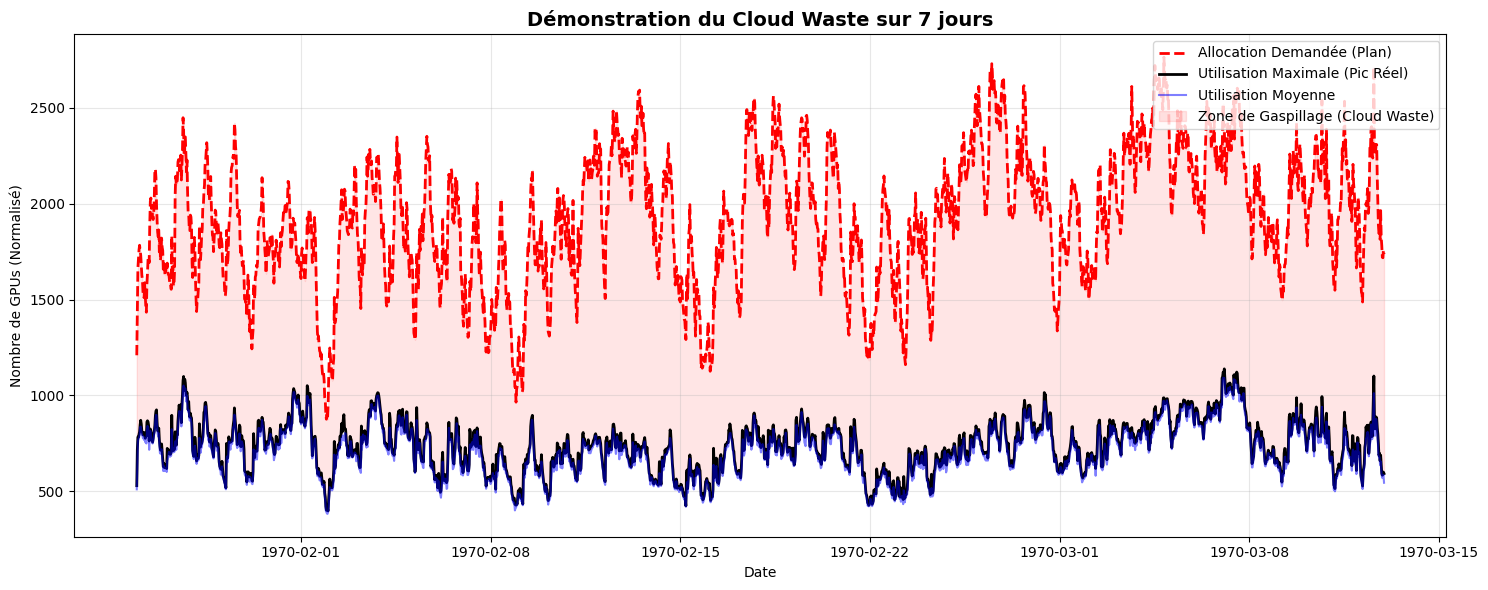

In [31]:

# Zoomer sur une semaine type en milieu de dataset
plt.figure(figsize=(15, 6))
plt.plot(df.index, df['plan_mean'], label='Allocation Demandée (Plan)', color='red', linestyle='--', linewidth=2)
plt.plot(df.index, df['util_max'], label='Utilisation Maximale (Pic Réel)', color='black', linewidth=2)
plt.plot(df.index, df['util_mean'], label='Utilisation Moyenne', color='blue', alpha=0.5)

plt.fill_between(df.index, df['util_max'], df['plan_mean'], color='red', alpha=0.1, label='Zone de Gaspillage (Cloud Waste)')

plt.title('Démonstration du Cloud Waste sur 7 jours', fontsize=14, fontweight='bold')
plt.ylabel('Nombre de GPUs (Normalisé)')
plt.xlabel('Date')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

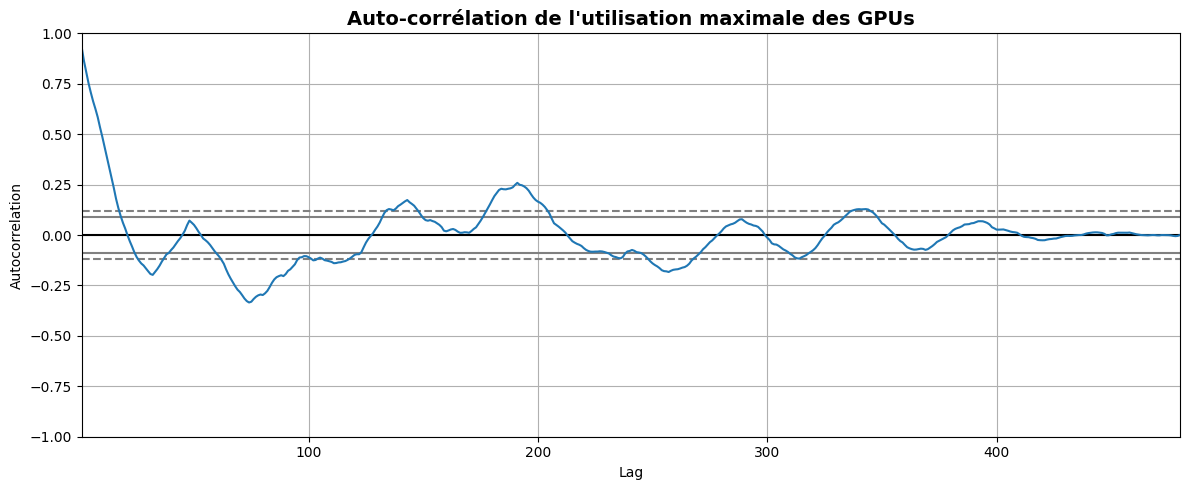

In [32]:
from pandas.plotting import autocorrelation_plot

plt.figure(figsize=(12, 5))
# On prend un échantillon de 10 jours pour voir la saisonnalité claire
autocorrelation_plot(df['util_max'].iloc[:480]) 
plt.title("Auto-corrélation de l'utilisation maximale des GPUs", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

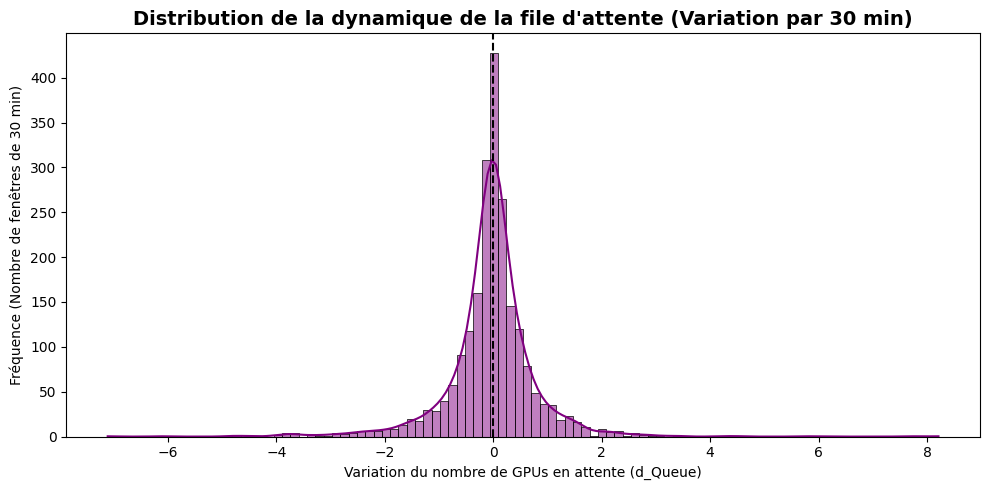

In [33]:
import seaborn as sns
plt.figure(figsize=(10, 5))
sns.histplot(df['queue_trend'], bins=100, color='purple', kde=True)

plt.title("Distribution de la dynamique de la file d'attente (Variation par 30 min)", fontsize=14, fontweight='bold')
plt.xlabel("Variation du nombre de GPUs en attente (d_Queue)")
plt.ylabel("Fréquence (Nombre de fenêtres de 30 min)")
plt.axvline(x=0, color='black', linestyle='--')
plt.tight_layout()
plt.show()